In [2]:
#import important libraaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_excel(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task6\Mall Customers.xlsx")

In [4]:
#first five rows
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [5]:
#dataset shape
df.shape

(200, 7)

In [6]:
#check for the missing values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
df.rename(columns={
    'Education ': 'Education',
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score',
    'Marital Status': 'Marital_Status'
}, inplace=True)

In [8]:
# =========================
# DATA PREPROCESSING
# =========================

# Encoding categorical columns
label_encoder = LabelEncoder()

df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['Education'] = label_encoder.fit_transform(df['Education'])
df['Marital_Status'] = label_encoder.fit_transform(df['Marital_Status'])

In [9]:
# =========================
# SELECT FEATURES
# =========================

X = df[[
    'Age',
    'Annual_Income',
    'Spending_Score',
    'Gender',
    'Education',
    'Marital_Status'
]]

In [10]:
# =========================
# FEATURE SCALING
# =========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# =========================
# ELBOW METHOD
# =========================

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

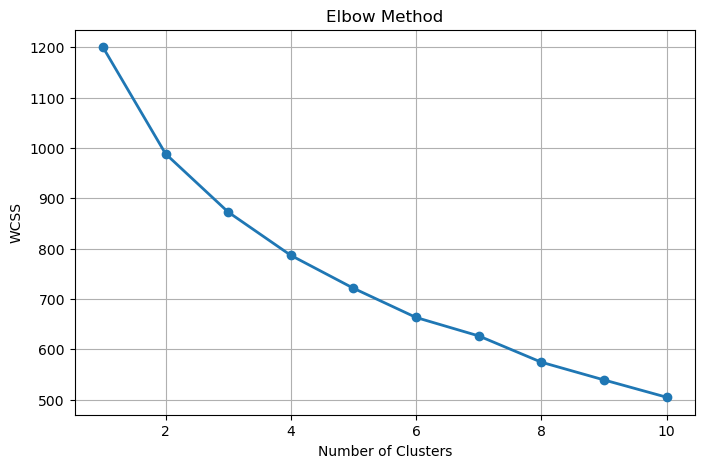

In [12]:
# =========================
# VISUALIZE ELBOW METHOD
# =========================

plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o', linewidth=2)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)

plt.savefig(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task6\elbow_method.png")
plt.show()


In [13]:
# =========================
# APPLY K-MEANS CLUSTERING
# =========================

# Optimal number of clusters = 5

kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels
df['Cluster'] = clusters


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [14]:
# =========================
# SILHOUETTE SCORE
# =========================

score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:")
print(round(score, 3))



Silhouette Score:
0.168


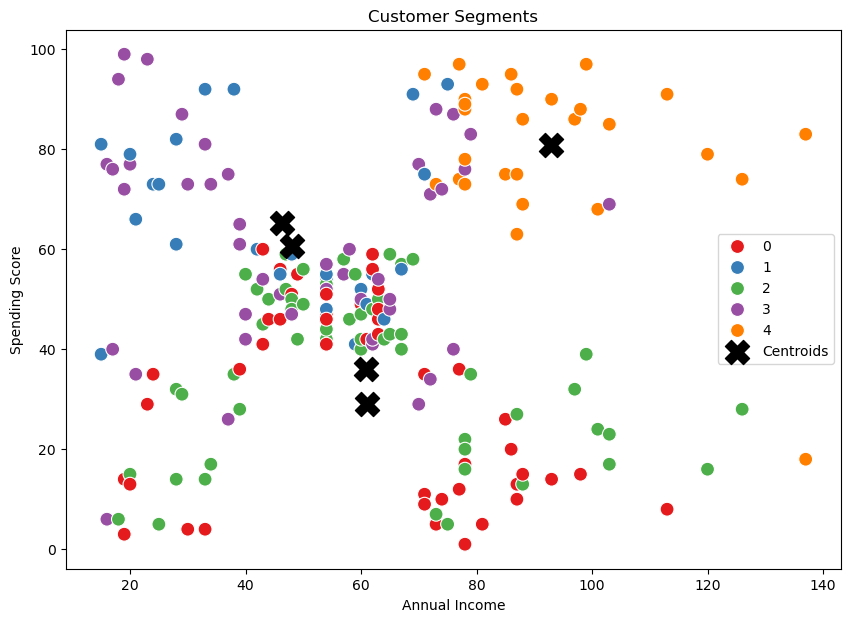

In [15]:
# =========================
# CLUSTER VISUALIZATION
# =========================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

# Cluster Centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:, 1],   # Annual Income
    centers[:, 2],   # Spending Score
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()

plt.savefig(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task6\customer_segments.png")
plt.show()


In [16]:
# =========================
# CLUSTER ANALYSIS
# =========================

print("\nCustomers in Each Cluster:\n")
print(df['Cluster'].value_counts())

print("\nCluster-wise Average Values:\n")

cluster_analysis = df.groupby('Cluster')[[
    'Age',
    'Annual_Income',
    'Spending_Score'
]].mean()

print(cluster_analysis)


Customers in Each Cluster:

Cluster
2    54
0    46
3    45
4    28
1    27
Name: count, dtype: int64

Cluster-wise Average Values:

               Age  Annual_Income  Spending_Score
Cluster                                          
0        50.021739      60.978261       29.043478
1        26.629630      46.370370       65.222222
2        48.648148      60.925926       36.037037
3        27.133333      48.088889       60.733333
4        32.214286      92.892857       80.857143


In [17]:
# =========================
# SAVE FINAL DATASET
# =========================

df.to_excel(r"C:\Users\Admin\OneDrive\Documents\Internship project\Task6\Mall_Customers_Segmented.xlsx", index=False)

In [2]:
# =========================
# CUSTOMER INSIGHTS
# =========================

import pandas as pd

# Load segmented dataset
df = pd.read_excel(
    r"C:\Users\Admin\OneDrive\Documents\Internship project\Task6\Mall_Customers_Segmented.xlsx"
)

# Cluster Analysis
cluster_analysis = df.groupby('Cluster')[[
    'Age',
    'Annual_Income',
    'Spending_Score'
]].mean()

print("=" * 60)
print("CUSTOMER SEGMENT INSIGHTS")
print("=" * 60)

for cluster in cluster_analysis.index:

    avg_age = cluster_analysis.loc[cluster, 'Age']
    avg_income = cluster_analysis.loc[cluster, 'Annual_Income']
    avg_spending = cluster_analysis.loc[cluster, 'Spending_Score']

    print(f"\nCluster {cluster}")
    print("-" * 30)

    print(f"Average Age: {avg_age:.2f}")
    print(f"Average Income: {avg_income:.2f} k$")
    print(f"Average Spending Score: {avg_spending:.2f}")

    if avg_income >= 70 and avg_spending >= 70:
        insight = "Premium Customers - High income and high spending."
    
    elif avg_income >= 70 and avg_spending < 40:
        insight = "Careful Customers - High income but low spending."
    
    elif avg_income < 40 and avg_spending >= 70:
        insight = "Impulsive Buyers - Lower income but high spending."
    
    elif avg_income < 40 and avg_spending < 40:
        insight = "Budget Customers - Low income and low spending."
    
    else:
        insight = "Average Customers - Moderate income and spending."

    print("Insight:", insight)

CUSTOMER SEGMENT INSIGHTS

Cluster 0
------------------------------
Average Age: 50.02
Average Income: 60.98 k$
Average Spending Score: 29.04
Insight: Average Customers - Moderate income and spending.

Cluster 1
------------------------------
Average Age: 26.63
Average Income: 46.37 k$
Average Spending Score: 65.22
Insight: Average Customers - Moderate income and spending.

Cluster 2
------------------------------
Average Age: 48.65
Average Income: 60.93 k$
Average Spending Score: 36.04
Insight: Average Customers - Moderate income and spending.

Cluster 3
------------------------------
Average Age: 27.13
Average Income: 48.09 k$
Average Spending Score: 60.73
Insight: Average Customers - Moderate income and spending.

Cluster 4
------------------------------
Average Age: 32.21
Average Income: 92.89 k$
Average Spending Score: 80.86
Insight: Premium Customers - High income and high spending.


In [3]:
# =========================
# SAVE INSIGHTS TO TEXT FILE
# =========================

with open("Customer_Insights.txt", "w", encoding="utf-8") as file:

    file.write("CUSTOMER SEGMENT INSIGHTS\n")
    file.write("=" * 60 + "\n\n")

    for cluster in cluster_analysis.index:

        avg_age = cluster_analysis.loc[cluster, 'Age']
        avg_income = cluster_analysis.loc[cluster, 'Annual_Income']
        avg_spending = cluster_analysis.loc[cluster, 'Spending_Score']

        file.write(f"Cluster {cluster}\n")
        file.write("-" * 30 + "\n")

        file.write(f"Average Age: {avg_age:.2f}\n")
        file.write(f"Average Income: {avg_income:.2f} k$\n")
        file.write(f"Average Spending Score: {avg_spending:.2f}\n")

        if avg_income >= 70 and avg_spending >= 70:
            insight = "Premium Customers - High income and high spending."

        elif avg_income >= 70 and avg_spending < 40:
            insight = "Careful Customers - High income but low spending."

        elif avg_income < 40 and avg_spending >= 70:
            insight = "Impulsive Buyers - Lower income but high spending."

        elif avg_income < 40 and avg_spending < 40:
            insight = "Budget Customers - Low income and low spending."

        else:
            insight = "Average Customers - Moderate income and spending."

        file.write(f"Insight: {insight}\n\n")

print("Customer insights saved successfully as 'Customer_Insights.txt'")

Customer insights saved successfully as 'Customer_Insights.txt'
